# Grafik örnekleri

Bar, heatmap, violin, pairplot ve box. Veri: `tips` (bahşiş verisi).

Paket yoksa: `pip install pandas matplotlib seaborn` veya not defterinde `%pip install pandas matplotlib seaborn`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Okunaklı bir tema
sns.set_theme(style="whitegrid", context="notebook")

# tips CSV (internet gerekir)
TIPS_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(TIPS_URL)
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## Bar (çubuk)

Günlük veya kategoriye göre ortalamaları yan yana görmek için.

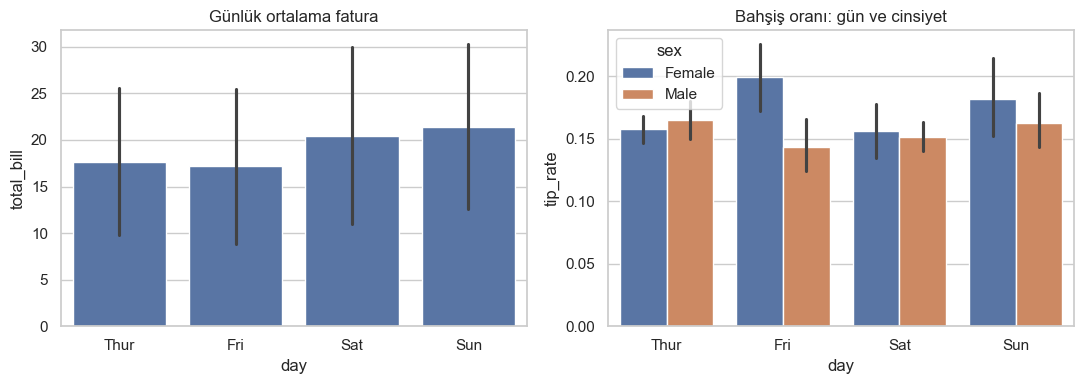

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Günlük ortalama fatura
sns.barplot(data=df, x="day", y="total_bill", estimator="mean", errorbar="sd", ax=axes[0], order=["Thur", "Fri", "Sat", "Sun"])
axes[0].set_title("Günlük ortalama fatura")

# Gün ve cinsiyete göre bahşiş oranı
df2 = df.copy()
df2["tip_rate"] = df2["tip"] / df2["total_bill"]
sns.barplot(
    data=df2,
    x="day",
    y="tip_rate",
    hue="sex",
    estimator="mean",
    errorbar="ci",
    ax=axes[1],
    order=["Thur", "Fri", "Sat", "Sun"],
)
axes[1].set_title("Bahşiş oranı: gün ve cinsiyet")
axes[1].legend(title="sex")
plt.tight_layout()
plt.show()

## Heatmap

Sayıları renkle göstermek; korelasyon veya pivot tablolar için uygun.

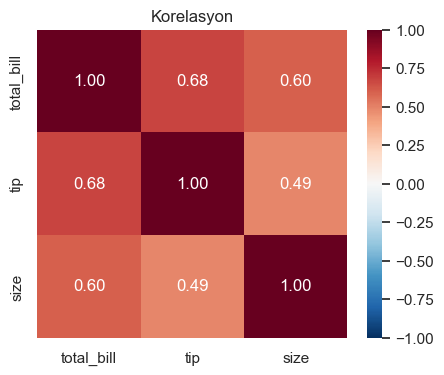

In [9]:
# Sayısal sütunlar için korelasyon
num_cols = ["total_bill", "tip", "size"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Korelasyon")
plt.show()

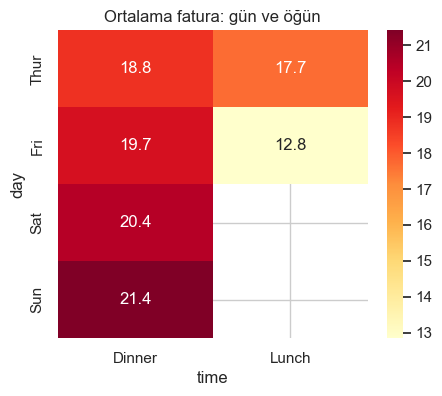

In [10]:
# Pivot: gün × öğün, ortalama fatura
pivot = df.pivot_table(values="total_bill", index="day", columns="time", aggfunc="mean")
pivot = pivot.reindex(["Thur", "Fri", "Sat", "Sun"])

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax)
ax.set_title("Ortalama fatura: gün ve öğün")
plt.show()

## Violin

Dağılımın şekli ve kalınlığı; grupları karşılaştırmak için.

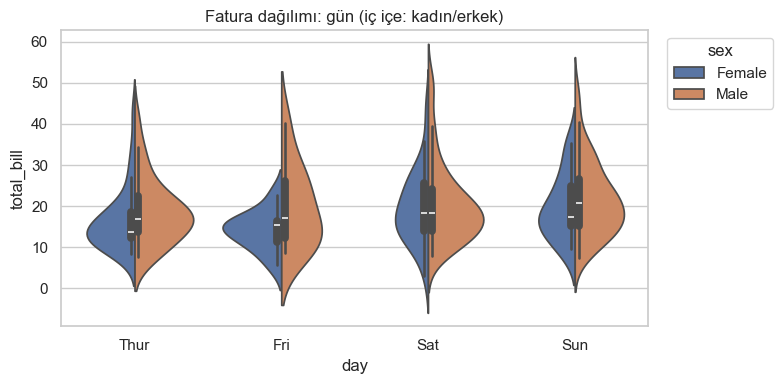

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.violinplot(data=df, x="day", y="total_bill", hue="sex", split=True, order=["Thur", "Fri", "Sat", "Sun"], ax=ax)
ax.set_title("Fatura: gün, kadın / erkek")
plt.legend(title="sex", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Pairplot

Birden çok sütunu tek bakışta; hangi değişkenler birlikte hareket ediyor, kabaca görmek için.

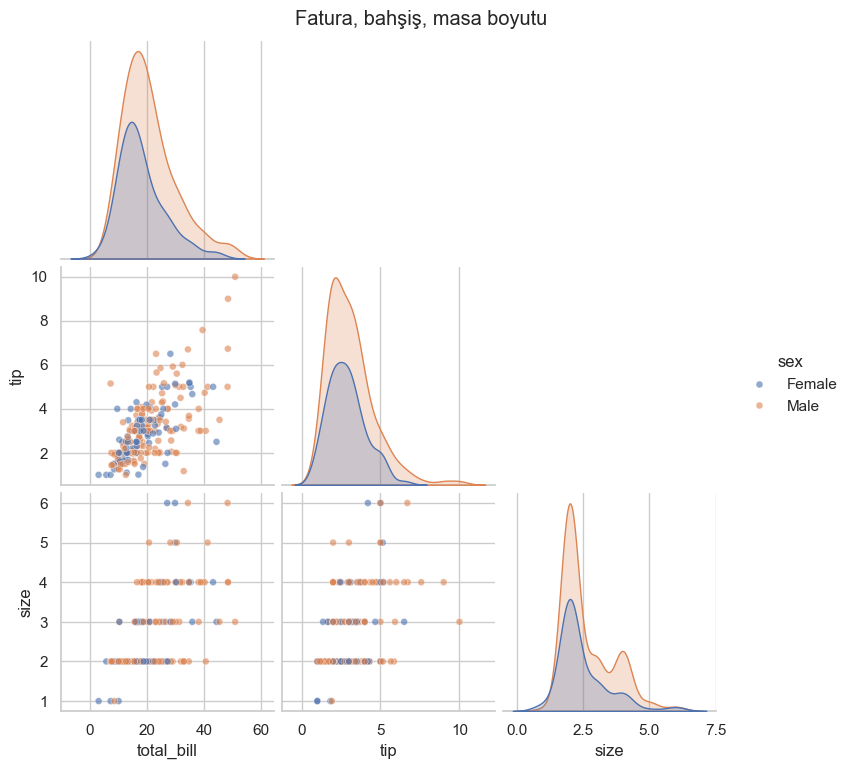

In [11]:
# Birkaç sütun + renkle kategori
g = sns.pairplot(
    df[["total_bill", "tip", "size", "sex"]],
    hue="sex",
    corner=True,
    plot_kws={"alpha": 0.6, "s": 25},
    diag_kind="kde",
)
g.fig.suptitle("Fatura, bahşiş, masa boyutu", y=1.02)
plt.show()

## Box (kutu)

Medyan, çeyrekler, aykırılar; süre veya skorları gruplara göre kıyaslamak için.

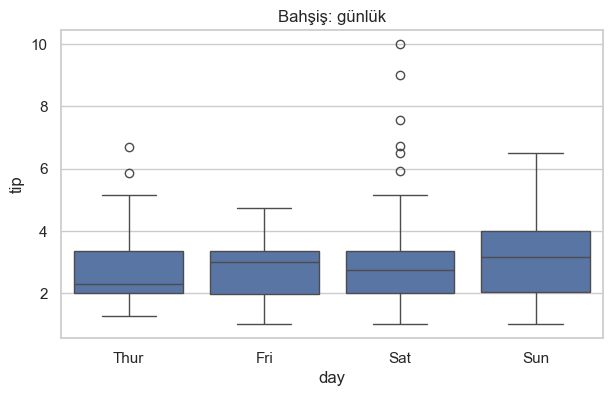

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x="day", y="tip", order=["Thur", "Fri", "Sat", "Sun"], ax=ax)
ax.set_title("Bahşiş: günlük")
plt.show()